In [1]:
import sys
print(sys.executable)


/home/leesungwon/miniconda3/envs/eda/bin/python


In [23]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

# p90 label dataset을 우선 로드합니다. p80/기존 파일을 보고 싶으면 순서를 바꾸면 됩니다.
DATASETS = {
    'mininet': [
        Path('../dataset_mininet_merged_p90.jsonl'),
        Path('dataset_mininet_merged_p90.jsonl'),
        Path('../dataset_mininet_merged.jsonl'),
        Path('dataset_mininet_merged.jsonl'),
        Path('../dataset.jsonl'),
        Path('dataset.jsonl'),
        Path('model/dataset.jsonl'),
        Path('../model/dataset.jsonl'),
    ],
    'univ1': [
        Path('../dataset_univ1_p90.jsonl'),
        Path('dataset_univ1_p90.jsonl'),
        Path('../dataset_univ1.jsonl'),
        Path('dataset_univ1.jsonl'),
        Path('model/dataset_univ1.jsonl'),
    ],
}

FEATURE_NAMES = [
    'frame_len',
    'ip_len',
    'ip_ttl',
    'tcp_payload_bytes',
    'tcp_flags',
    'tcp_window_size',
    'iat_us',
    'retransmission',
    'out_of_order',
    'duplicate_ack',
    'fast_retransmission',
]

MASKED_FEATURES = [
    'retransmission',
    'out_of_order',
    'duplicate_ack',
    'fast_retransmission',
]


def resolve_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('dataset jsonl 파일을 찾지 못했습니다: ' + ', '.join(map(str, candidates)))


def load_flow_dataset(path, dataset_name):
    meta_rows = []
    packet_rows = []

    with Path(path).open('r', encoding='utf-8') as f:
        for row_id, line in enumerate(f, start=1):
            if not line.strip():
                continue

            sample = json.loads(line)
            flow_key = sample.get('flow_key', {})
            trace_key = sample.get('trace_key', {})
            x = np.asarray(sample.get('x', []), dtype=float)

            if x.ndim != 2 or x.shape[1] != len(FEATURE_NAMES):
                raise ValueError(f'{path}:{row_id} x shape이 예상과 다릅니다: {x.shape}')

            src_index = flow_key.get('src_index', 0)
            flow_id = flow_key.get('flow_id', flow_key.get('tcp_stream', row_id))
            source_file = flow_key.get('source_file', trace_key.get('source_file', ''))
            tcp_stream = flow_key.get('tcp_stream', trace_key.get('tcp_stream', np.nan))
            direction = flow_key.get('direction', '')
            run_id = sample.get('run_id', '')
            directional_size = sample.get('directional_size_bytes', 0)
            flow_size = sample.get('flow_size_bytes', directional_size)
            label = sample.get('label')

            tcp_payload = x[:, FEATURE_NAMES.index('tcp_payload_bytes')]
            iat = x[:, FEATURE_NAMES.index('iat_us')]
            tcp_flags = x[:, FEATURE_NAMES.index('tcp_flags')]

            meta = {
                'dataset': dataset_name,
                'row_id': row_id,
                'run_id': run_id,
                'src_index': src_index,
                'flow_id': flow_id,
                'source_file': source_file,
                'tcp_stream': tcp_stream,
                'direction': direction,
                'direction_label': f'{direction} L{label}',
                'directional_size_bytes': directional_size,
                'flow_size_bytes': flow_size,
                'label': label,
                'packet_count': x.shape[0],
                'x_mean': float(x.mean()),
                'cum_payload_10': float(tcp_payload.sum()),
                'payload_packet_count_10': int((tcp_payload > 0).sum()),
                'full_payload_packet_count_10': int((tcp_payload >= 1400).sum()),
                'elapsed_iat_us_10': float(iat.sum()),
                'mean_iat_us_10': float(iat.mean()),
                'max_iat_us_10': float(iat.max()),
                'seen_fin_10': int(((tcp_flags.astype(int) & 0x01) > 0).any()),
                'seen_rst_10': int(((tcp_flags.astype(int) & 0x04) > 0).any()),
            }

            for col_idx, feature_name in enumerate(FEATURE_NAMES):
                values = x[:, col_idx]
                meta[f'{feature_name}_mean'] = float(values.mean())
                meta[f'{feature_name}_first'] = float(values[0])
                meta[f'{feature_name}_last'] = float(values[-1])
                meta[f'{feature_name}_max'] = float(values.max())

            meta_rows.append(meta)

            for packet_index, values in enumerate(x):
                packet_row = {
                    'dataset': dataset_name,
                    'row_id': row_id,
                    'run_id': run_id,
                    'flow_id': flow_id,
                    'source_file': source_file,
                    'tcp_stream': tcp_stream,
                    'direction': direction,
                    'direction_label': f'{direction} L{label}',
                    'packet_index': packet_index,
                    'label': label,
                    'flow_size_bytes': flow_size,
                    'directional_size_bytes': directional_size,
                }
                packet_row.update(dict(zip(FEATURE_NAMES, values)))
                packet_rows.append(packet_row)

    return pd.DataFrame(meta_rows), pd.DataFrame(packet_rows)


loaded = {}
flow_frames = []
packet_frames = []

for dataset_name, candidates in DATASETS.items():
    dataset_path = resolve_path(candidates)
    flow_df, flow_packet_df = load_flow_dataset(dataset_path, dataset_name)
    loaded[dataset_name] = dataset_path
    flow_frames.append(flow_df)
    packet_frames.append(flow_packet_df)

all_df = pd.concat(flow_frames, ignore_index=True)
all_packet_df = pd.concat(packet_frames, ignore_index=True)

mininet_df = all_df[all_df['dataset'] == 'mininet'].copy()
univ1_df = all_df[all_df['dataset'] == 'univ1'].copy()
mininet_packet_df = all_packet_df[all_packet_df['dataset'] == 'mininet'].copy()
univ1_packet_df = all_packet_df[all_packet_df['dataset'] == 'univ1'].copy()

print('loaded paths:')
for name, dataset_path in loaded.items():
    print(f'- {name}: {dataset_path}')

print('')
print('flow counts by dataset/label:')
print(all_df.groupby(['dataset', 'label']).size())
print('')
print('flow counts by dataset/direction/label:')
print(all_df.groupby(['dataset', 'direction', 'label']).size())

masked_nonzero = all_packet_df[MASKED_FEATURES].to_numpy().sum()
print(f'\nmasked feature nonzero sum: {masked_nonzero:g}')

display(all_df.groupby('dataset')[['flow_size_bytes', 'directional_size_bytes', 'cum_payload_10', 'elapsed_iat_us_10']].agg(['count', 'mean', 'median', 'min', 'max']))
display(all_df.head())


loaded paths:
- mininet: ../dataset_mininet_merged_p90.jsonl
- univ1: ../dataset_univ1_p90.jsonl

flow counts by dataset/label:
dataset  label
mininet  0          8762
         1           975
univ1    0        107161
         1         11911
dtype: int64

flow counts by dataset/direction/label:
dataset  direction   label
mininet  dst_to_src  0         3745
                     1          975
         src_to_dst  0         5017
univ1    dst_to_src  0        60388
                     1        10760
         src_to_dst  0        46773
                     1         1151
dtype: int64

masked feature nonzero sum: 0


flow_size_bytes                                        \
                  count          mean   median min        max   
dataset                                                         
mininet            9737  1.030522e+06     20.0  20  646328655   
univ1            119072  8.567802e+04  10667.0   0  682769160   

        directional_size_bytes                                        \
                         count          mean   median min        max   
dataset                                                                
mininet                   9737  1.030522e+06     20.0  20  646328655   
univ1                   119072  8.567802e+04  10667.0   0  682769160   

        cum_payload_10                                     elapsed_iat_us_10  \
                 count         mean  median   min      max             count   
dataset                                                                        
mininet           9737  6197.307282    20.0  20.0  13052.0              9737   
univ1           119072  5295.415832  4984.0   0.0  14600.0            119072   

                                                    
                 mean    median   min          max  
dataset                                             
mininet  1.474720e+04    1807.0   9.0     335912.0  
univ1    4.165119e+06  539583.5  73.0  338297214.0

,dataset,row_id,run_id,src_index,flow_id,source_file,tcp_stream,direction,direction_label,directional_size_bytes,...,out_of_order_last,out_of_order_max,duplicate_ack_mean,duplicate_ack_first,duplicate_ack_last,duplicate_ack_max,fast_retransmission_mean,fast_retransmission_first,fast_retransmission_last,fast_retransmission_max
0,mininet,1,mininet_001,0,2,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,mininet,2,mininet_001,0,3,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,mininet,3,mininet_001,0,5,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,mininet,4,mininet_001,0,7,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,mininet,5,mininet_001,0,10,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


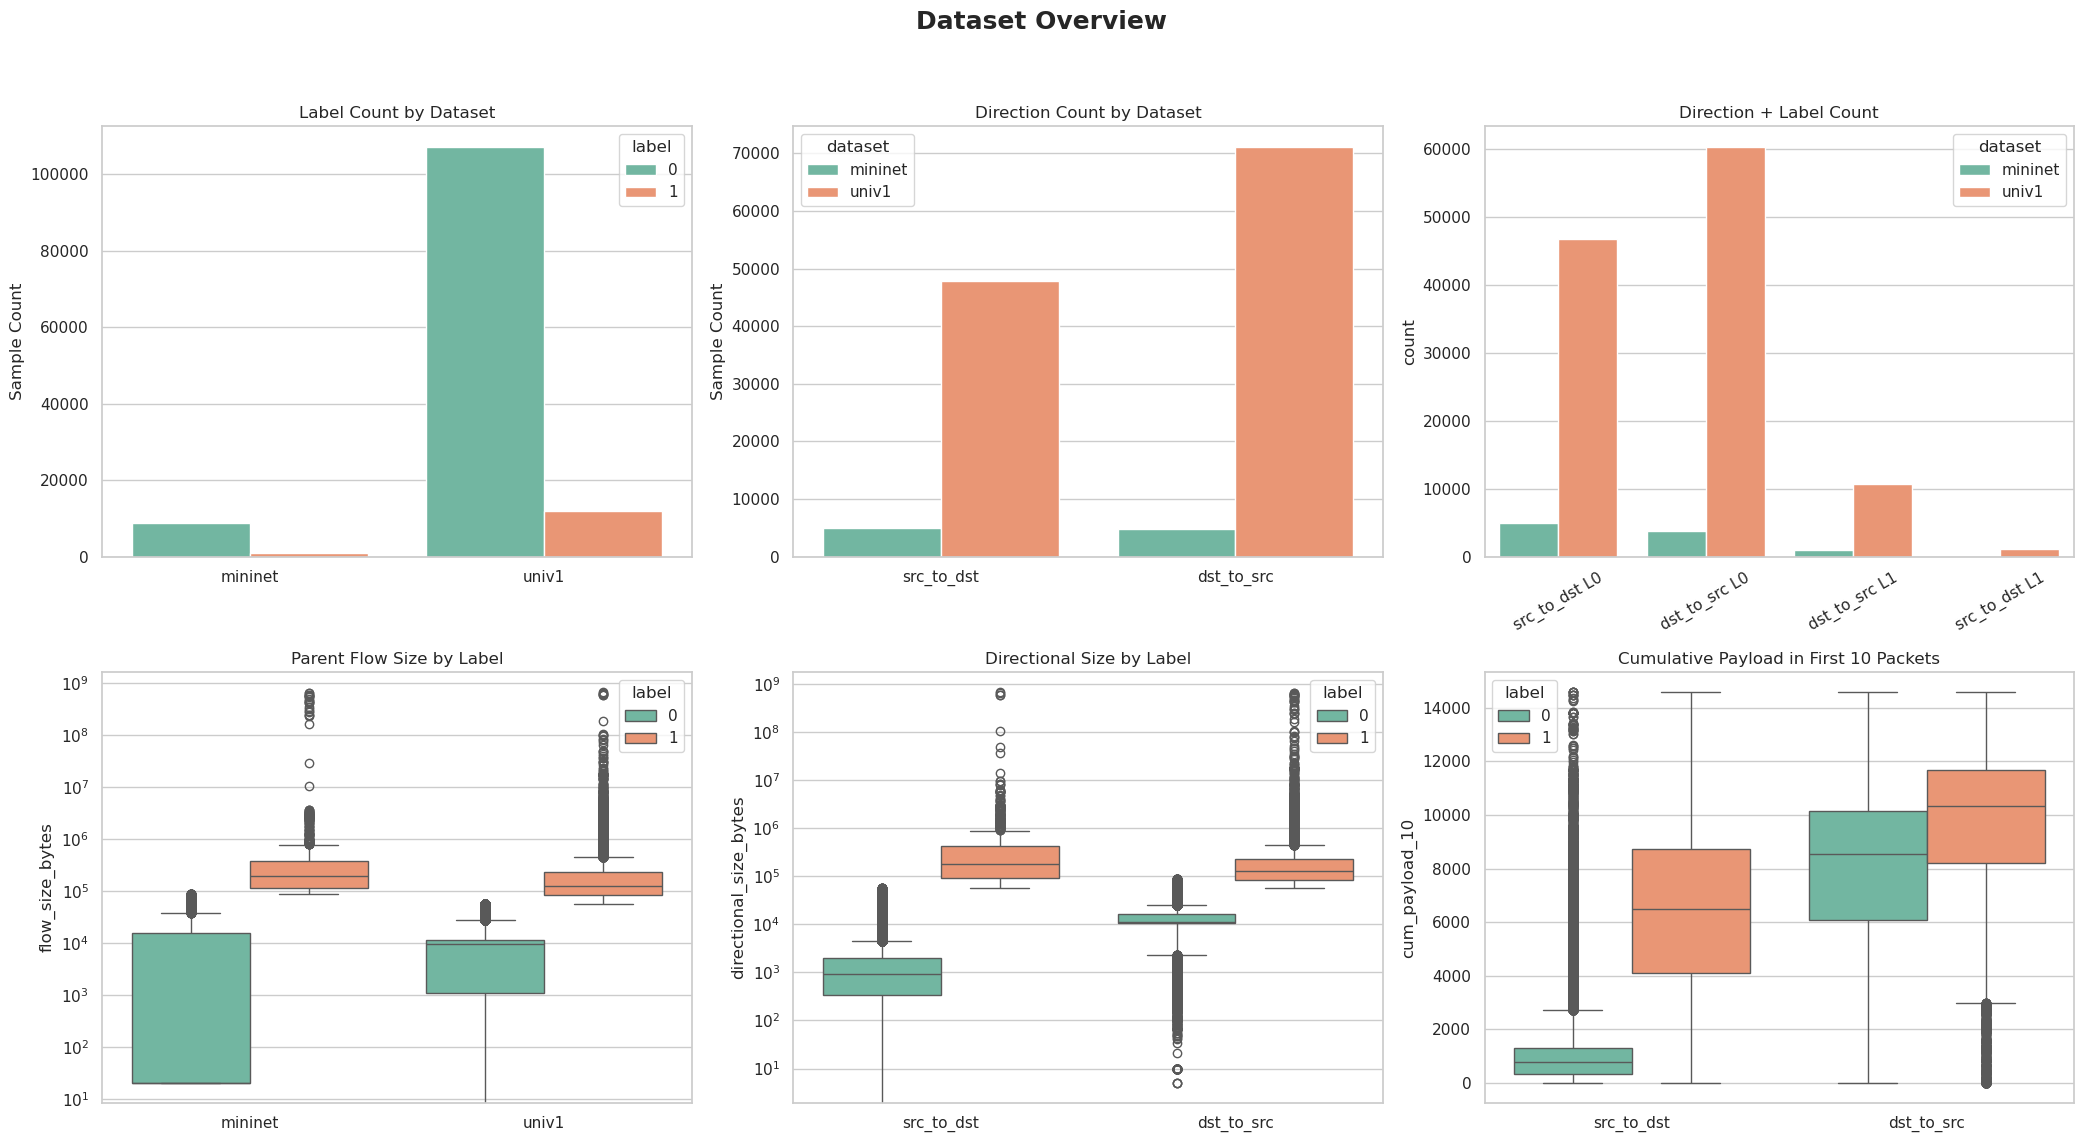

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('Dataset Overview', fontsize=18, fontweight='bold')

sns.countplot(x='dataset', hue='label', data=all_df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Label Count by Dataset')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Sample Count')

sns.countplot(x='direction', hue='dataset', data=all_df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Direction Count by Dataset')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Sample Count')

sns.countplot(x='direction_label', hue='dataset', data=all_df, ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Direction + Label Count')
axes[0, 2].set_xlabel('')
axes[0, 2].tick_params(axis='x', rotation=30)

sns.boxplot(x='dataset', y='flow_size_bytes', hue='label', data=all_df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Parent Flow Size by Label')
axes[1, 0].set_xlabel('')

sns.boxplot(x='direction', y='directional_size_bytes', hue='label', data=all_df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Directional Size by Label')
axes[1, 1].set_xlabel('')

sns.boxplot(x='direction', y='cum_payload_10', hue='label', data=all_df, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Cumulative Payload in First 10 Packets')
axes[1, 2].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


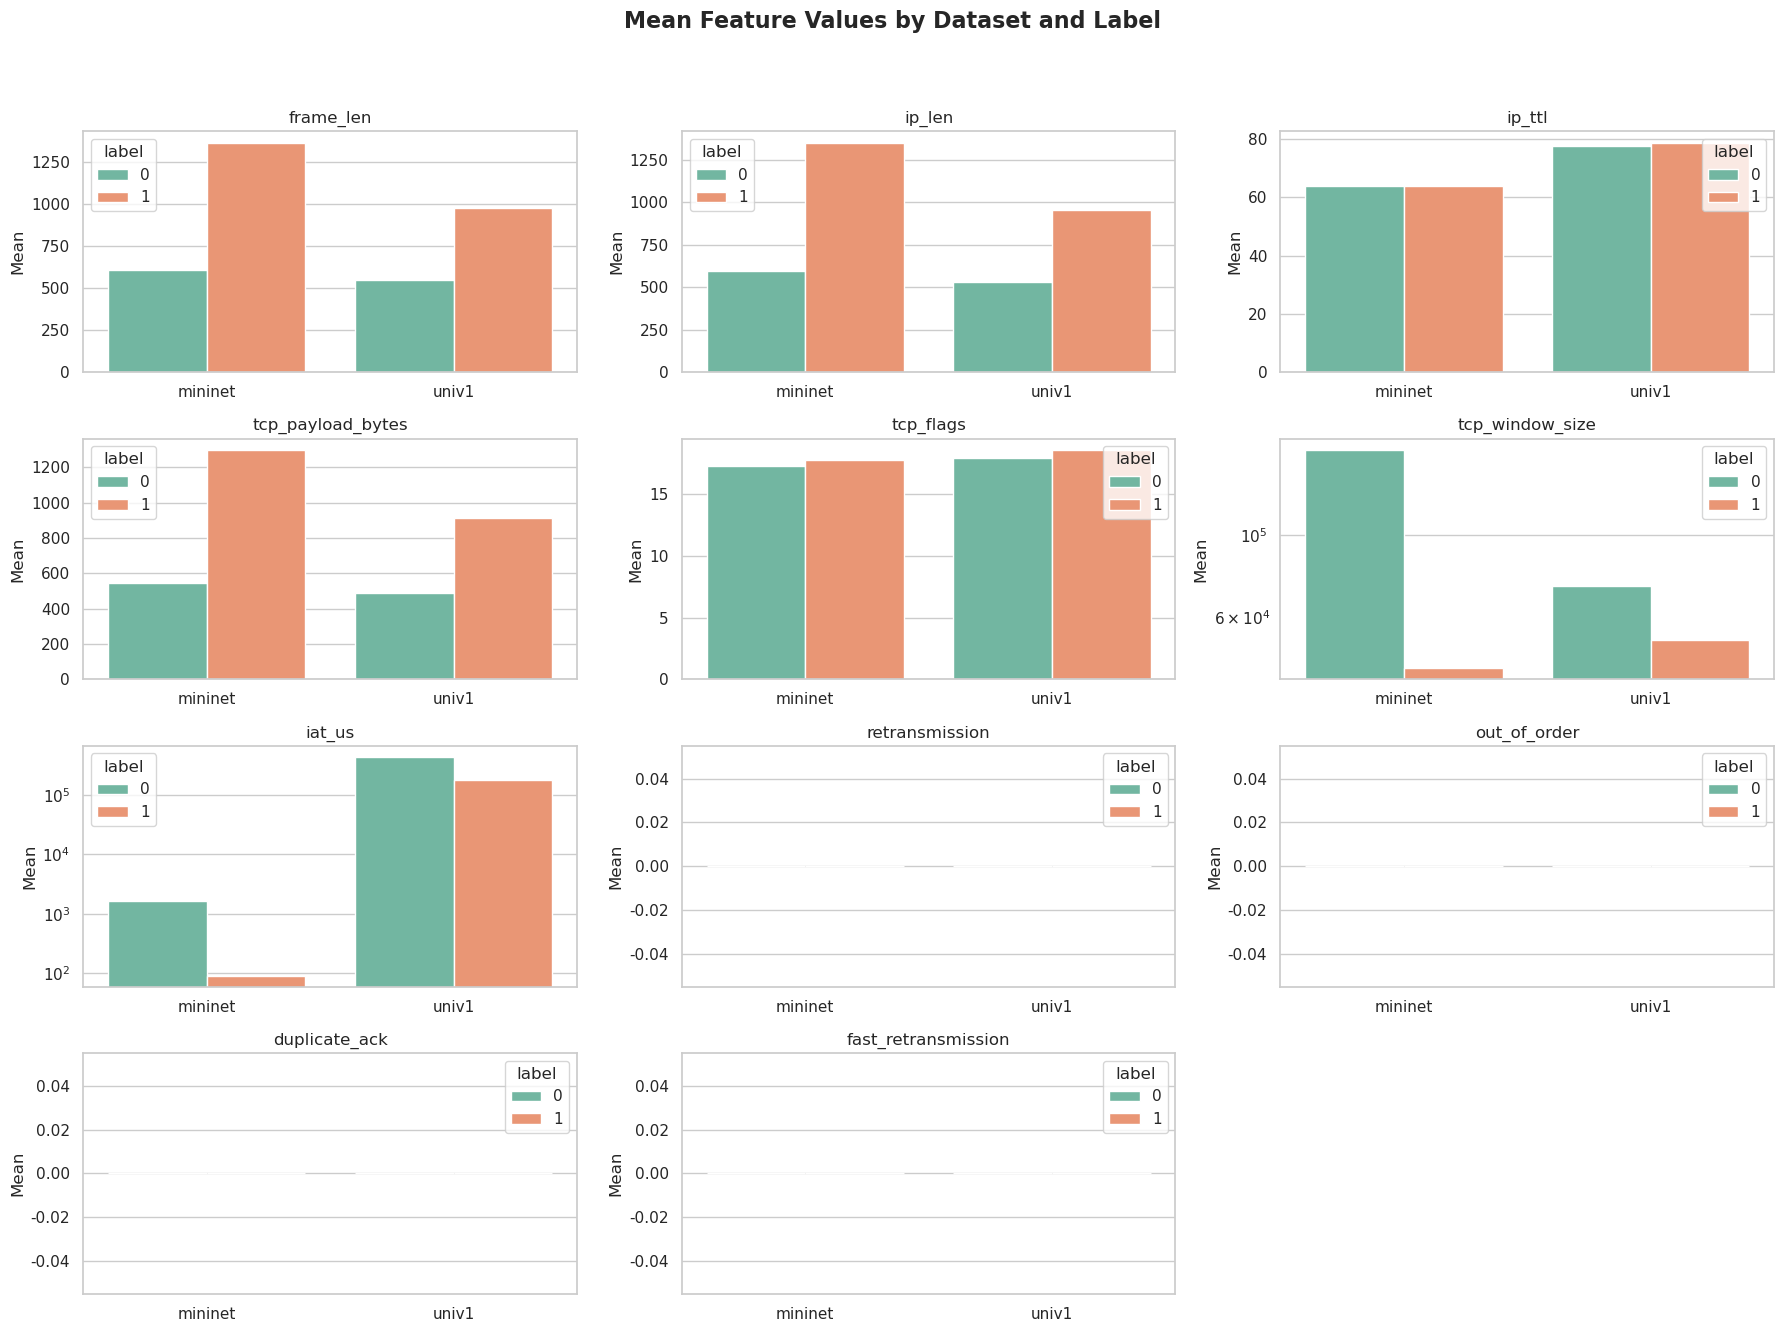

In [25]:
feature_mean_cols = [f'{name}_mean' for name in FEATURE_NAMES]
feature_compare = all_df.groupby(['dataset', 'label'])[feature_mean_cols].mean().reset_index()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Mean Feature Values by Dataset and Label', fontsize=16, fontweight='bold')

for i, feature_name in enumerate(FEATURE_NAMES):
    ax = axes[i // 3, i % 3]
    sns.barplot(
        x='dataset',
        y=f'{feature_name}_mean',
        hue='label',
        data=feature_compare,
        ax=ax,
        palette='Set2',
    )
    if feature_name in ['iat_us', 'tcp_window_size']:
        ax.set_yscale('log')
    ax.set_title(feature_name)
    ax.set_xlabel('')
    ax.set_ylabel('Mean')

axes[3, 2].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


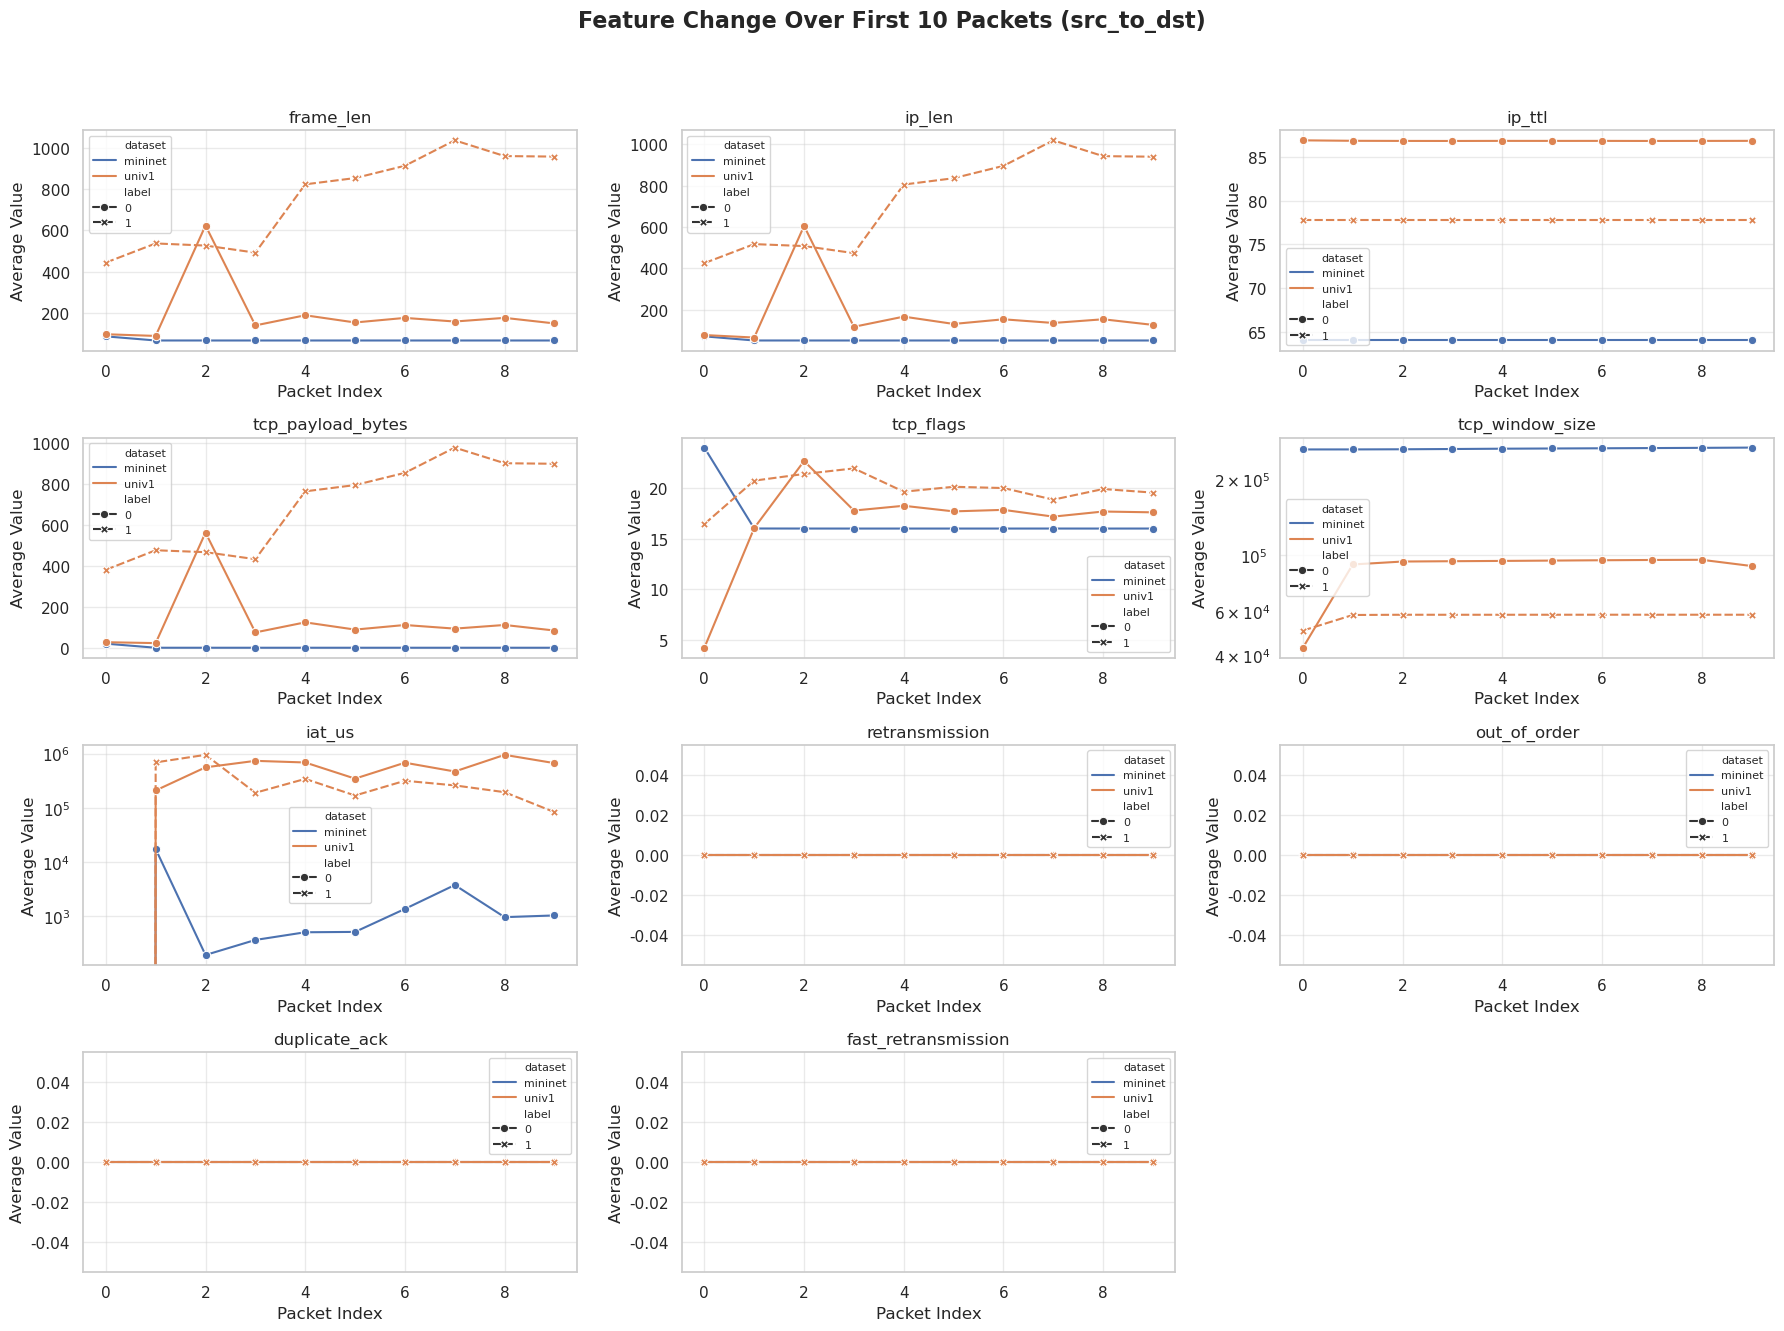

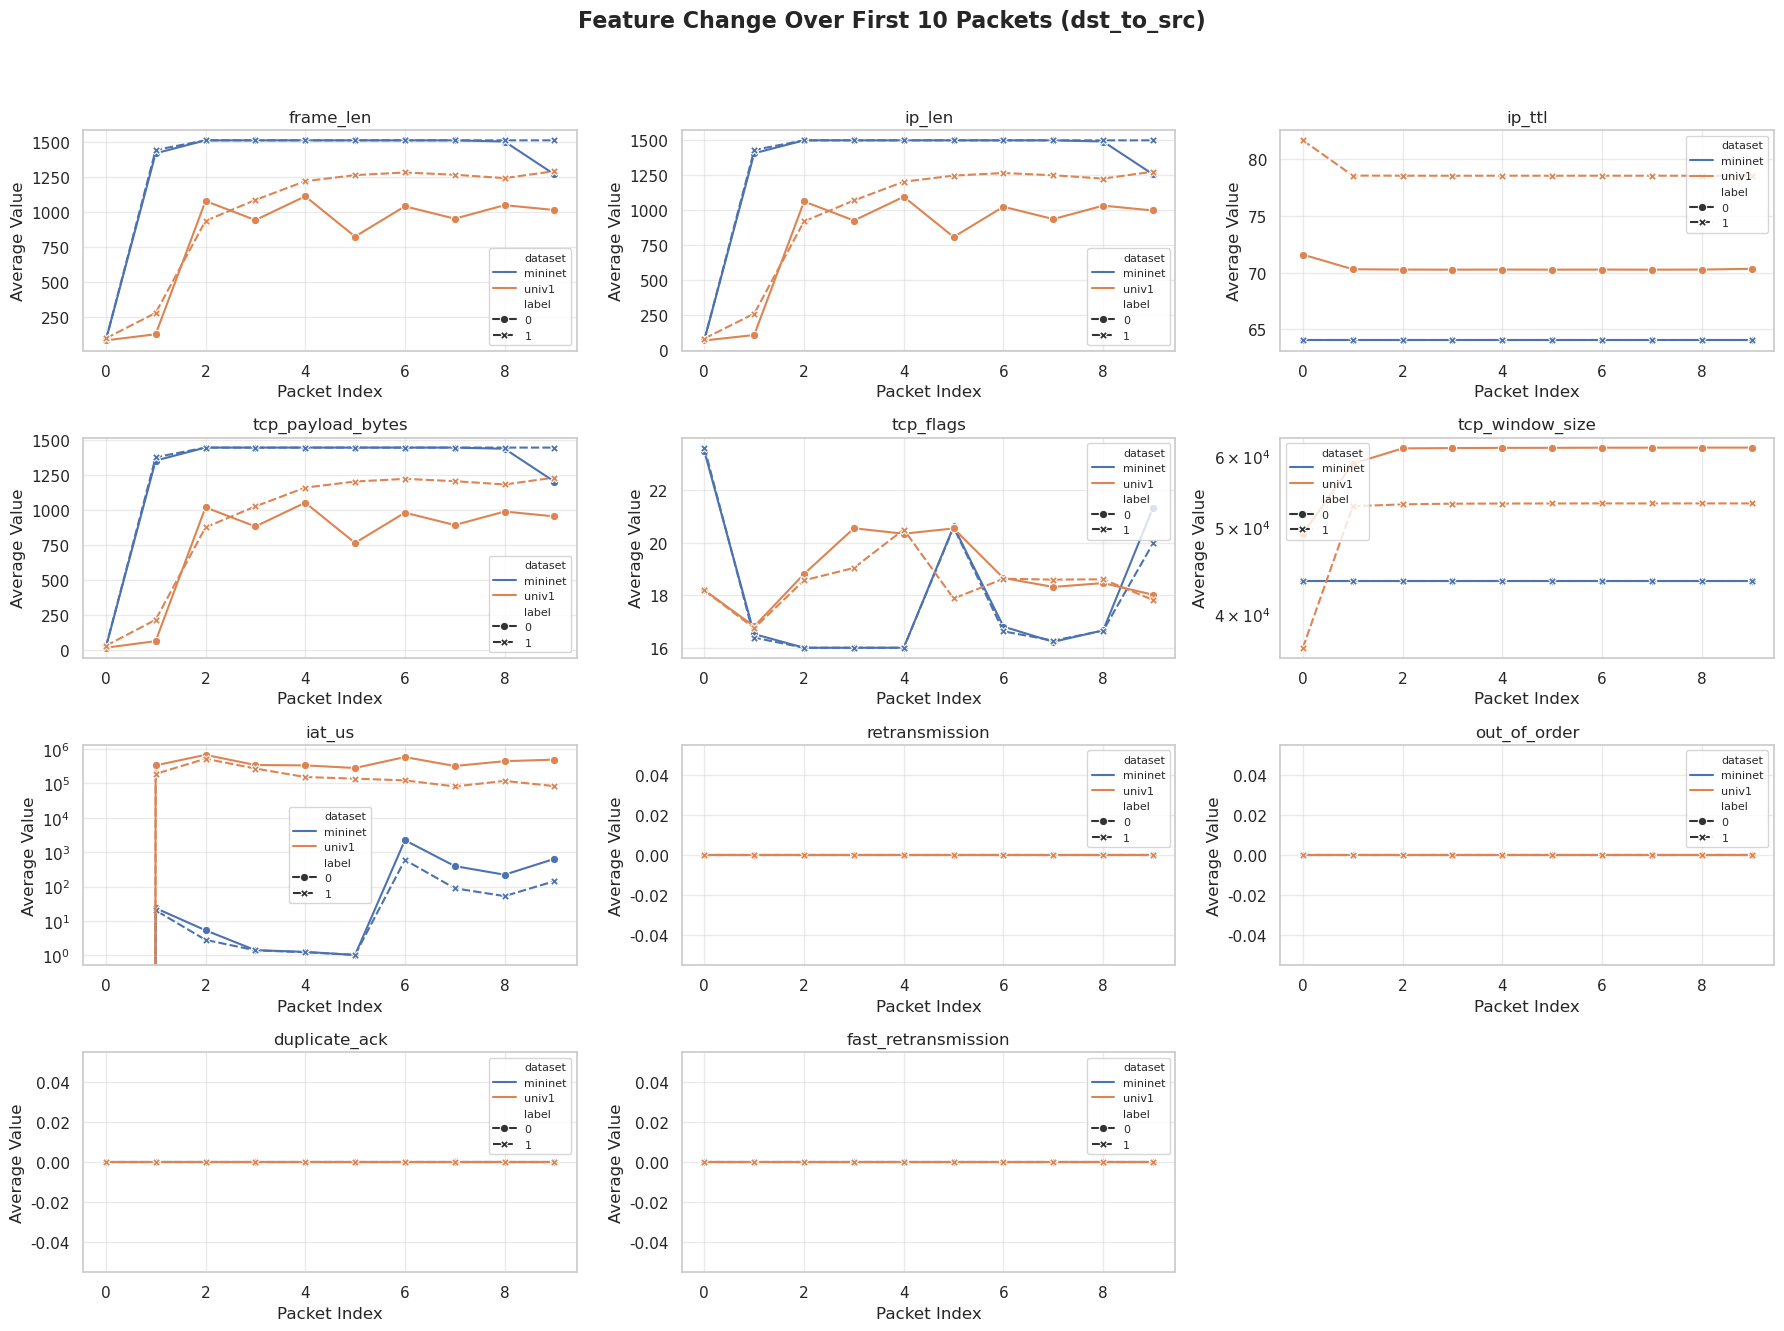

In [27]:
# 예전 그래프와 같은 방식: direction을 섞고 dataset/label 기준으로만 평균냅니다.
avg_mixed_by_label = all_packet_df.groupby(['dataset', 'label', 'packet_index'])[FEATURE_NAMES].mean().reset_index()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Feature Change Over First 10 Packets (direction mixed)', fontsize=16, fontweight='bold')

for i, feature_name in enumerate(FEATURE_NAMES):
    ax = axes[i // 3, i % 3]
    sns.lineplot(
        data=avg_mixed_by_label,
        x='packet_index',
        y=feature_name,
        hue='dataset',
        style='label',
        markers=True,
        dashes=True,
        ax=ax,
    )
    if feature_name in ['iat_us', 'tcp_window_size']:
        ax.set_yscale('log')
    ax.set_title(feature_name)
    ax.set_xlabel('Packet Index')
    ax.set_ylabel('Average Value')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

axes[3, 2].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('direction mix by dataset/label:')
print(all_df.groupby(['dataset', 'label', 'direction']).size())

# 필요할 때 순수 direction별 차이도 확인할 수 있도록 별도 plot은 남겨둡니다.
avg_by_direction_label = all_packet_df.groupby(['dataset', 'direction', 'label', 'packet_index'])[FEATURE_NAMES].mean().reset_index()

for direction in ['src_to_dst', 'dst_to_src']:
    fig, axes = plt.subplots(4, 3, figsize=(18, 14))
    fig.suptitle(f'Feature Change Over First 10 Packets ({direction})', fontsize=16, fontweight='bold')

    for i, feature_name in enumerate(FEATURE_NAMES):
        ax = axes[i // 3, i % 3]
        subset = avg_by_direction_label[avg_by_direction_label['direction'] == direction]
        sns.lineplot(
            data=subset,
            x='packet_index',
            y=feature_name,
            hue='dataset',
            style='label',
            markers=True,
            dashes=True,
            ax=ax,
        )
        if feature_name in ['iat_us', 'tcp_window_size']:
            ax.set_yscale('log')
        ax.set_title(feature_name)
        ax.set_xlabel('Packet Index')
        ax.set_ylabel('Average Value')
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8)

    axes[3, 2].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



In [6]:
summary = all_df.groupby(['dataset', 'label'])[['flow_size_bytes', 'directional_size_bytes', 'x_mean'] + feature_mean_cols].agg(['mean', 'median', 'std'])
summary


flow_size_bytes                         directional_size_bytes  \
                         mean    median           std                   mean   
dataset label                                                                  
mininet 0        3.316073e+04   21759.0  3.234116e+04           1.717348e+04   
        1        1.719428e+07  356600.0  8.746192e+07           8.597151e+06   
univ1   0        2.000223e+04   11579.0  1.882969e+04           1.237436e+04   
        1        1.164625e+06  177836.0  1.822301e+07           5.982918e+05   

                                            x_mean                \
                median           std          mean        median   
dataset label                                                      
mininet 0         20.0  2.804364e+04  14625.724662   4677.600000   
        1      72204.5  6.244012e+07  14586.550458   4361.477273   
univ1   0      10443.0  1.599224e+04  47539.853138  10983.672727   
        1      99327.0  1.289889e+07  22733.625000   9454.763636   

                             frame_len_mean  ... retransmission_mean  \
                         std           mean  ...                 std   
dataset label                                ...                       
mininet 0       15478.954010     681.685956  ...                 0.0   
        1       15519.706133     715.958957  ...                 0.0   
univ1   0      182483.333128     590.594459  ...                 0.0   
        1      158336.657951     603.616970  ...                 0.0   

              out_of_order_mean             duplicate_ack_mean              \
                           mean median  std               mean median  std   
dataset label                                                                
mininet 0                   0.0    0.0  0.0                0.0    0.0  0.0   
        1                   0.0    0.0  0.0                0.0    0.0  0.0   
univ1   0                   0.0    0.0  0.0                0.0    0.0  0.0   
        1                   0.0    0.0  0.0                0.0    0.0  0.0   

              fast_retransmission_mean              
                                  mean median  std  
dataset label                                       
mininet 0                          0.0    0.0  0.0  
        1                          0.0    0.0  0.0  
univ1   0                          0.0    0.0  0.0  
        1                          0.0    0.0  0.0  

[4 rows x 42 columns]

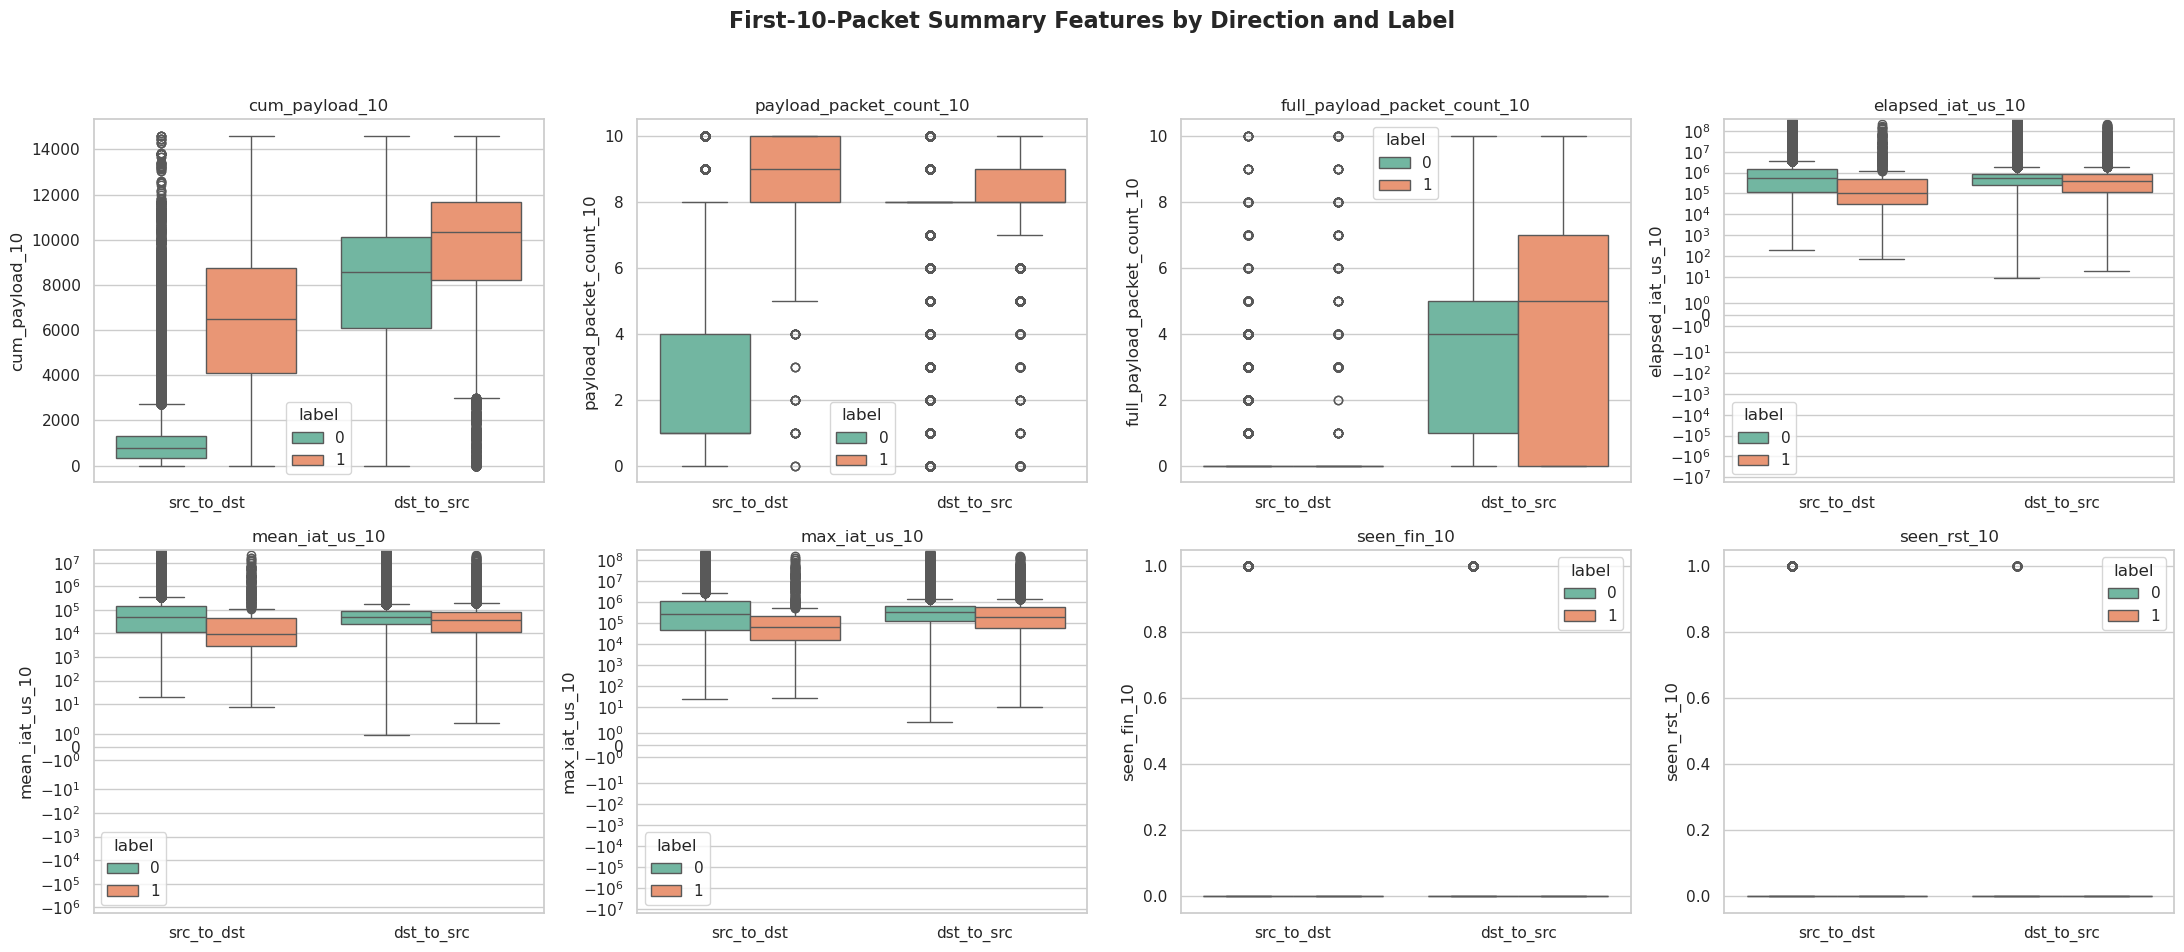

cum_payload_10                                  \
                                  count          mean   median      min   
dataset direction  label                                                  
mininet dst_to_src 0               3745  12706.290254  13052.0   8928.0   
                   1                975  12982.198974  13052.0  11604.0   
        src_to_dst 0               5017     20.027905     20.0     20.0   
univ1   dst_to_src 0              60388   7633.597917   8402.0      0.0   
                   1              10760   9372.818773   9962.0      0.0   
        src_to_dst 0              46773   1298.163299    862.0      0.0   
                   1               1151   6939.635969   6489.0      0.0   

                                  payload_packet_count_10                   \
                              max                   count      mean median   
dataset direction  label                                                     
mininet dst_to_src 0      13052.0                    3745  9.935113   10.0   
                   1      13052.0                     975  9.951795   10.0   
        src_to_dst 0         60.0                    5017  1.001395    1.0   
univ1   dst_to_src 0      14600.0                   60388  7.602835    8.0   
                   1      14600.0                   10760  7.829740    8.0   
        src_to_dst 0      14600.0                   46773  2.709384    1.0   
                   1      14600.0                    1151  8.625543    9.0   

                                  ... flow_size_bytes                          \
                         min max  ...           count          mean    median   
dataset direction  label          ...                                           
mininet dst_to_src 0       9  10  ...            3745  2.749359e+04   19854.0   
                   1       9  10  ...             975  1.018577e+07  196836.0   
        src_to_dst 0       1   3  ...            5017  2.017540e+01      20.0   
univ1   dst_to_src 0       0  10  ...           60388  1.460715e+04   11313.0   
                   1       0  10  ...           10760  5.512298e+05  123978.0   
        src_to_dst 0       0  10  ...           46773  3.201551e+03    1042.0   
                   1       0  10  ...            1151  2.813881e+06  175665.0   

                                           directional_size_bytes  \
                            min        max                  count   
dataset direction  label                                            
mininet dst_to_src 0       8928      87025                   3745   
                   1      87091  646328655                    975   
        src_to_dst 0         20         60                   5017   
univ1   dst_to_src 0          0      55977                  60388   
                   1      55992  627037592                  10760   
        src_to_dst 0          0      55875                  46773   
                   1      56351  682769160                   1151   

                                                                    
                                  mean    median    min        max  
dataset direction  label                                            
mininet dst_to_src 0      2.749359e+04   19854.0   8928      87025  
                   1      1.018577e+07  196836.0  87091  646328655  
        src_to_dst 0      2.017540e+01      20.0     20         60  
univ1   dst_to_src 0      1.460715e+04   11313.0      0      55977  
                   1      5.512298e+05  123978.0  55992  627037592  
        src_to_dst 0      3.201551e+03    1042.0      0      55875  
                   1      2.813881e+06  175665.0  56351  682769160  

[7 rows x 50 columns]

In [28]:
# Direction별 초기 10패킷 요약 feature 비교
summary_features = [
    'cum_payload_10',
    'payload_packet_count_10',
    'full_payload_packet_count_10',
    'elapsed_iat_us_10',
    'mean_iat_us_10',
    'max_iat_us_10',
    'seen_fin_10',
    'seen_rst_10',
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('First-10-Packet Summary Features by Direction and Label', fontsize=16, fontweight='bold')

for i, feature in enumerate(summary_features):
    ax = axes[i // 4, i % 4]
    sns.boxplot(
        data=all_df,
        x='direction',
        y=feature,
        hue='label',
        ax=ax,
        palette='Set2',
    )
    if feature in ['elapsed_iat_us_10', 'mean_iat_us_10', 'max_iat_us_10']:
        ax.set_yscale('symlog')
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

display(all_df.groupby(['dataset', 'direction', 'label'])[summary_features + ['flow_size_bytes', 'directional_size_bytes']].agg(['count', 'mean', 'median', 'min', 'max']))


In [8]:
# Mininet에서 같은 payload/flags 패턴이 label 양쪽에 얼마나 섞이는지 확인
pattern_rows = []
for _, row in mininet_df.iterrows():
    packets = mininet_packet_df[mininet_packet_df['row_id'] == row['row_id']].sort_values('packet_index')
    pattern = tuple(zip(packets['tcp_payload_bytes'].astype(int), packets['tcp_flags'].astype(int)))
    pattern_rows.append({
        'row_id': row['row_id'],
        'direction': row['direction'],
        'label': row['label'],
        'pattern': pattern,
    })

pattern_df = pd.DataFrame(pattern_rows)
pattern_summary = (
    pattern_df
    .groupby(['direction', 'pattern'])
    .agg(count=('label', 'size'), label1=('label', 'sum'))
    .reset_index()
)
pattern_summary['label1_ratio'] = pattern_summary['label1'] / pattern_summary['count']

display(pattern_summary.sort_values('count', ascending=False).head(20))


,direction,pattern,count,label1,label1_ratio
1091,src_to_dst,"((20, 24), (0, 16), (0, 16), (0, 16), (0, 16),...",5011,573,0.114348
1090,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",1509,239,0.158383
338,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",595,115,0.193277
1089,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",454,84,0.185022
417,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",259,35,0.135135
79,dst_to_src,"((0, 16), (20, 24), (1448, 16), (1448, 16), (1...",211,29,0.137441
339,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",191,34,0.178010
495,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",116,20,0.172414
448,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",107,19,0.177570
1088,dst_to_src,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",4,0,0.000000
